In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
print("kernel working")

kernel working


2024-07-12    225.0
2024-07-19    225.0
2024-07-26    225.0
2024-08-02    225.0
2024-08-09    225.0
              ...  
2026-06-05    225.0
2026-06-12    225.0
2026-06-19    225.0
2026-06-26    225.0
2026-07-03    225.0
Freq: W-FRI, Length: 104, dtype: float64


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

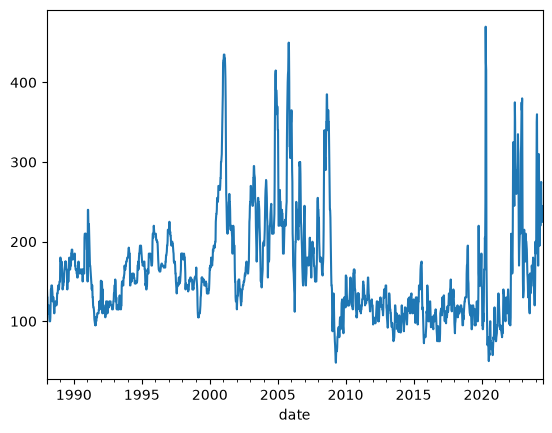

In [3]:
#TC5 Exponential Smoothing model

#load dataset
tc5_rates = pd.read_csv("../data/ras_tanura_chiba_clean_55k_rates.csv")
tc5_rates.head()
tc5_rates.columns

#model
tc5_rates["date"] = pd.to_datetime(
    tc5_rates["date"],
    format="%d/%m/%y"
)

tc5_rates = tc5_rates.sort_values("date")
tc5_rates = tc5_rates.set_index("date")

series = tc5_rates["worldscale_rate"]

train_tc5 = series[:-104]
test_tc5 = series[-104:]

tc5_model = ExponentialSmoothing(train_tc5, trend = None, seasonal = None, seasonal_periods = 52)



fit_tc5= tc5_model.fit()
pred_tc5 = fit_tc5.forecast(len(test_tc5))
print(pred_tc5)

train_tc5.plot()


48.0 470.0
105.0 700.0
225.0000000745058 225.0000000745058
128.1971154333307
182.14451019851066
55.922912176672256


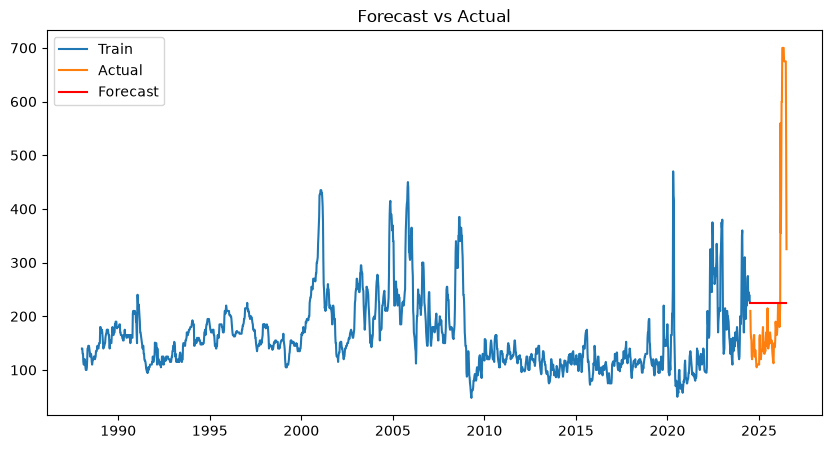

In [4]:
#evaluating model performance
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
#evaluate exponential smoothing performance 
print(train_tc5.min(), train_tc5.max())
print(test_tc5.min(), test_tc5.max())
print(pred_tc5.min(), pred_tc5.max())

pred = pred_tc5.copy()
pred.index = test_tc5.index

results =pd.DataFrame({"actual" : test_tc5, "predicted": pred})
results.head()

mae = mean_absolute_error(results["actual"], results["predicted"])
print(mae)

rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(rmse)

mape = (abs(results["actual"] - results["predicted"])/results["actual"]).mean()*100
print(mape)

#visualize results of model 
plt.figure(figsize=(10,5))
plt.plot(train_tc5, label="Train")
plt.plot(test_tc5, label="Actual")
plt.plot(pred, label="Forecast", color="red")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.


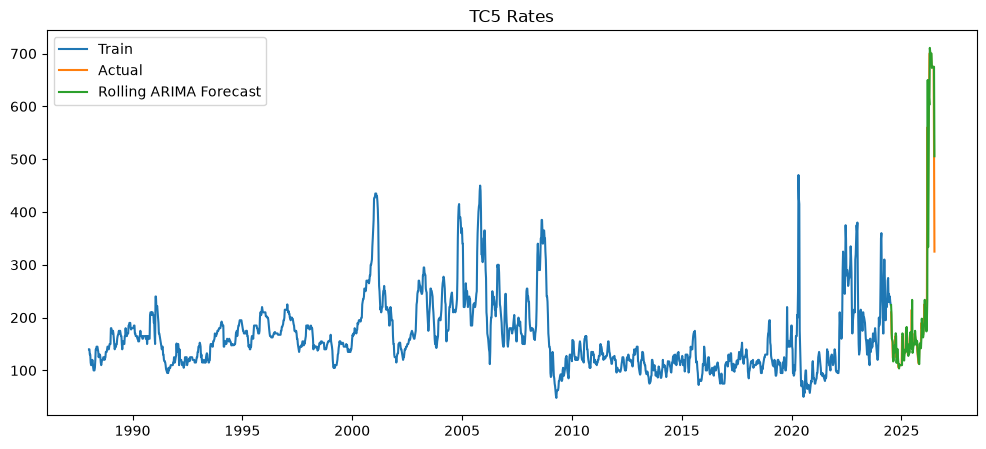

In [5]:
#now make rolling ARIMA model to get better accuracy 
from statsmodels.tsa.arima.model import ARIMA
tc5_series = tc5_rates["worldscale_rate"]

arima_train_tc5 = tc5_series.iloc[:-104]
arima_test_tc5 = tc5_series.iloc[-104:]

history = train_tc5.copy()
predictions_tc5 = []

for actual in arima_test_tc5:

    model = ARIMA(history, order=(1,1,1))
    fit = model.fit()

    forecast = fit.forecast(steps=2)
    predictions_tc5.append(forecast.iloc[0])

    # Add the actual observed value before predicting the next week
    history = pd.concat([history, pd.Series([actual])])

predictions_tc5 = pd.Series(predictions_tc5, index=test_tc5.index)


#graph to see results 
plt.figure(figsize=(12,5))

plt.plot(arima_train_tc5.index, arima_train_tc5, label="Train")
plt.plot(arima_test_tc5.index, arima_test_tc5, label="Actual")
plt.plot(predictions_tc5.index, predictions_tc5, label="Rolling ARIMA Forecast")
plt.title("TC5 Rates")
plt.legend()
plt.show()

In [6]:
#error metrics 
print(arima_train_tc5.min(), arima_train_tc5.max())
print(arima_test_tc5.min(), arima_test_tc5.max())
print(predictions_tc5.min(), predictions_tc5.max())

pred = predictions_tc5.copy()
pred.index = arima_test_tc5.index

results =pd.DataFrame({"actual" : arima_test_tc5, "predicted": pred})
results.head()

mae = mean_absolute_error(results["actual"], results["predicted"])
print(mae)

rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(rmse)

mape = (abs(results["actual"] - results["predicted"])/results["actual"]).mean()*100
print(mape)

48.0 470.0
105.0 700.0
103.73699188786935 710.7443649978359
23.80030875438729
56.19621676725342
9.599885002409536


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


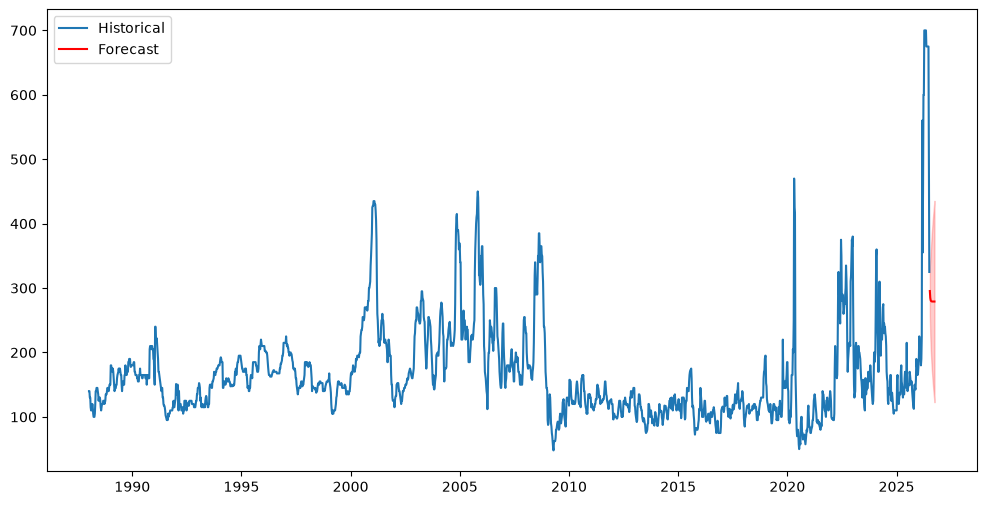

In [7]:
#future predictions for the next 12 weeks
series_future_tc5 = tc5_rates["worldscale_rate"]
final_model_tc5 = ARIMA(series_future_tc5, order = (1,1,1))
final_fit_tc5 = final_model_tc5.fit()
#get forecast and corresponding stats
future_tc5 = final_fit_tc5.get_forecast(steps=12)
future_mean_tc5 = future_tc5.predicted_mean
future_ci_tc5 = future_tc5.conf_int()
#add dates for forecasts
future_index_tc5 = pd.date_range(start=series_future_tc5.index[-1] + pd.Timedelta(weeks=1), periods = 12, freq = "W")
future_mean_tc5.index = future_index_tc5
future_ci_tc5.index = future_index_tc5

#forecast
forecast_df_tc5 = pd.DataFrame({"Forecast": future_mean_tc5,
                            "Lower95": future_ci_tc5.iloc[:,0],
                            "Upper95" : future_ci_tc5.iloc[:,1]
                            })
forecast_df_tc5

#visualize results
plt.figure(figsize = (12,6))
plt.plot(series_future_tc5, label = "Historical")
plt.plot(future_mean_tc5, color = "red", label = "Forecast")
plt.fill_between(future_ci_tc5.index, future_ci_tc5.iloc[:,0], future_ci_tc5.iloc[:,1], color = "red", alpha = .2)
plt.legend()
plt.show()